# 📊 Sentiment Analysis & Word Cloud: YouTube Comments "Rupiah Melemah"
**Summer Project - Data Analysis & Sentiment Analysis**

This notebook contains the complete data & sentiment analysis workflow directly from the Kaggle dataset `dzikriraihan/indonesian-youtube-comments-rupiah-melemah`:
1. Automatic Data Loading from **Kaggle Hub** (`kagglehub`)
2. Indonesian Text Cleaning & Preprocessing
3. Sentiment Labeling (Positive, Negative, Neutral)
4. Sentiment Distribution Summary & Visualization (Pie Chart & Bar Chart)
5. **Word Cloud** Visualization (Positive vs Negative)

---

### 1. Import Libraries

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from wordcloud import WordCloud

plt.style.use('ggplot')
print('Libraries loaded successfully!')

Libraries loaded successfully!


### 2. Load Dataset Directly from Kaggle

In [2]:
# Download / Load dataset directly from Kaggle automatically
try:
    print("Loading dataset from Kagglehub...")
    path = kagglehub.dataset_download("dzikriraihan/indonesian-youtube-comments-rupiah-melemah")
    csv_path = os.path.join(path, "Comment Youtube Rupiah melemah.csv")
    df = pd.read_csv(csv_path)
    print(f"Successfully loaded dataset from Kaggle! Total rows: {len(df)}")
except Exception as e:
    print(f"Failed to load from Kaggle, fallback to local file: {e}")
    df = pd.read_csv('rupiah_melemah_comments.csv')

df.head()

Loading dataset from Kagglehub...


Successfully loaded dataset from Kaggle! Total rows: 17840


,Video ID,Comment ID,Comment Link,Commenter Name,Commenter ID,Comment,Likes
0,sB7fSPbYFJg,UgycdW9c-JHCjxy6sTB4AaABAg,https://www.youtube.com/watch?v=sB7fSPbYFJg&lc...,@ArkanUkail-s1b,UCl5ayjbjB7U0FnkO9MvjgIA,Loh bukannya kejadian ini terjadinya di tahun ...,0
1,sB7fSPbYFJg,UgxRD2BGMzVJX4jxtTN4AaABAg,https://www.youtube.com/watch?v=sB7fSPbYFJg&lc...,@balldestroyer16,UCiYr_VCB_bRYMxX-QPqJ8OA,Damn kok kebetulan banget yah?,0
2,sB7fSPbYFJg,UgyDw5owDtUJC3yWrWd4AaABAg,https://www.youtube.com/watch?v=sB7fSPbYFJg&lc...,@AUFAL_RIVALS,UCMvlFGGxhxqSQ5nOia4z7jg,ku kira baru upload 🗿,0
3,sB7fSPbYFJg,UgwMIdFZwH2xIi7I0G14AaABAg,https://www.youtube.com/watch?v=sB7fSPbYFJg&lc...,@ddoddo5,UCanS1fV2JP98gBgOssTgdqA,algoritmanya bisa pas banget gini ya haha,0
4,sB7fSPbYFJg,UgzfJiQq4c9hiROxffF4AaABAg,https://www.youtube.com/watch?v=sB7fSPbYFJg&lc...,@RaniaXiaomi,UCjxCe7IgEItMvuSzABGh1jA,apakah ini cmn kebetulan lewat doang?,0


### 3. Text Cleaning & Sentiment Labeling

In [3]:
# Indonesian sentiment dictionary
POSITIVE_WORDS = set([
    'menguat', 'bagus', 'mantap', 'aman', 'hebat', 'dukung', 'percaya', 'optimis', 'baik', 'setuju',
    'senang', 'untung', 'stabil', 'maju', 'juara', 'semangat', 'positif', 'berhasil', 'sukses',
    'solusi', 'bangga', 'keren', 'paham', 'bijak', 'rezeki', 'berkah', 'semoga', 'amiin', 'amin'
])

NEGATIVE_WORDS = set([
    'melemah', 'hancur', 'korupsi', 'bohong', 'miskin', 'parah', 'rusak', 'rugi', 'anjlok', 'gagal',
    'becus', 'ngeles', 'bacot', 'nyocot', 'drama', 'ancam', 'beban', 'turun', 'bencana', 'utang',
    'stres', 'kasihan', 'kelaparan', 'benci', 'goblok', 'tolol', 'bodoh', 'sengsara', 'krisis'
])

SLANG_MAP = {
    'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'dgn': 'dengan',
    'sdh': 'sudah', 'udh': 'sudah', 'sy': 'saya', 'skrg': 'sekarang', 'utk': 'untuk',
    'bgt': 'banget', 'tp': 'tapi', 'sm': 'sama', 'dr': 'dari', 'klo': 'kalau',
    'kl': 'kalau', 'lg': 'lagi', 'trs': 'terus', 'jd': 'jadi', 'aja': 'saja'
}

NEGATION_WORDS = set(['tidak', 'bukan', 'jangan', 'tanpa', 'kurang'])

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'&[a-z0-9]+;', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = [SLANG_MAP.get(w, w) for w in text.split()]
    return " ".join(words)

def get_sentiment(text):
    cleaned = clean_text(text)
    words = cleaned.split()
    pos_score, neg_score = 0, 0
    for i, word in enumerate(words):
        is_negated = i > 0 and words[i-1] in NEGATION_WORDS
        if word in POSITIVE_WORDS:
            if is_negated:
                neg_score += 1
            else:
                pos_score += 1
        elif word in NEGATIVE_WORDS:
            if is_negated:
                pos_score += 1
            else:
                neg_score += 1
    net = pos_score - neg_score
    label = 'Positive' if net > 0 else ('Negative' if net < 0 else 'Neutral')
    return pd.Series([cleaned, label], index=['Cleaned_Comment', 'Sentiment'])

print('Processing cleaning & sentiment analysis...')
df[['Cleaned_Comment', 'Sentiment']] = df['Comment'].apply(get_sentiment)
print('Analysis process completed!')

Processing cleaning & sentiment analysis...


Analysis process completed!


### 4. Sentiment Summary Results

In [4]:
summary_df = pd.DataFrame({
    'Count': df['Sentiment'].value_counts(),
    'Percentage (%)': (df['Sentiment'].value_counts(normalize=True) * 100).round(2)
})
summary_df

,Count,Percentage (%)
Sentiment,,
Neutral,13246,74.25
Positive,2358,13.22
Negative,2236,12.53


### 5. Sentiment Distribution Visualization

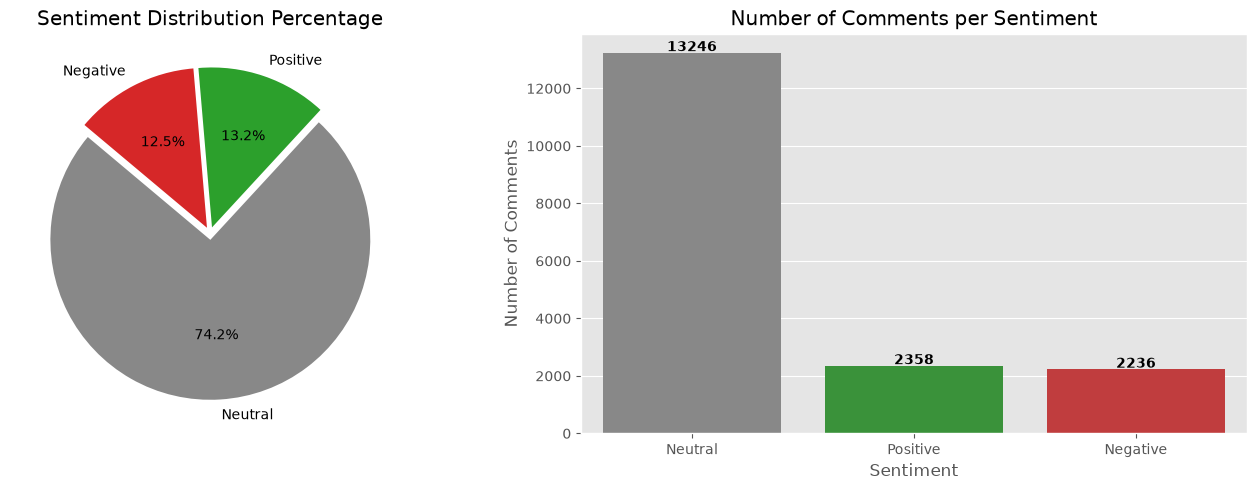

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df['Sentiment'].value_counts()
colors = ['#888888', '#2ca02c', '#d62728']

# Pie Chart
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=140, explode=(0.04, 0.04, 0.04))
axes[0].set_title('Sentiment Distribution Percentage')

# Bar Chart
sns.barplot(x=counts.index, y=counts.values, ax=axes[1], hue=counts.index, palette=colors, legend=False)
axes[1].set_title('Number of Comments per Sentiment')
axes[1].set_ylabel('Number of Comments')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 6. Word Cloud Visualization (Positive vs Negative)

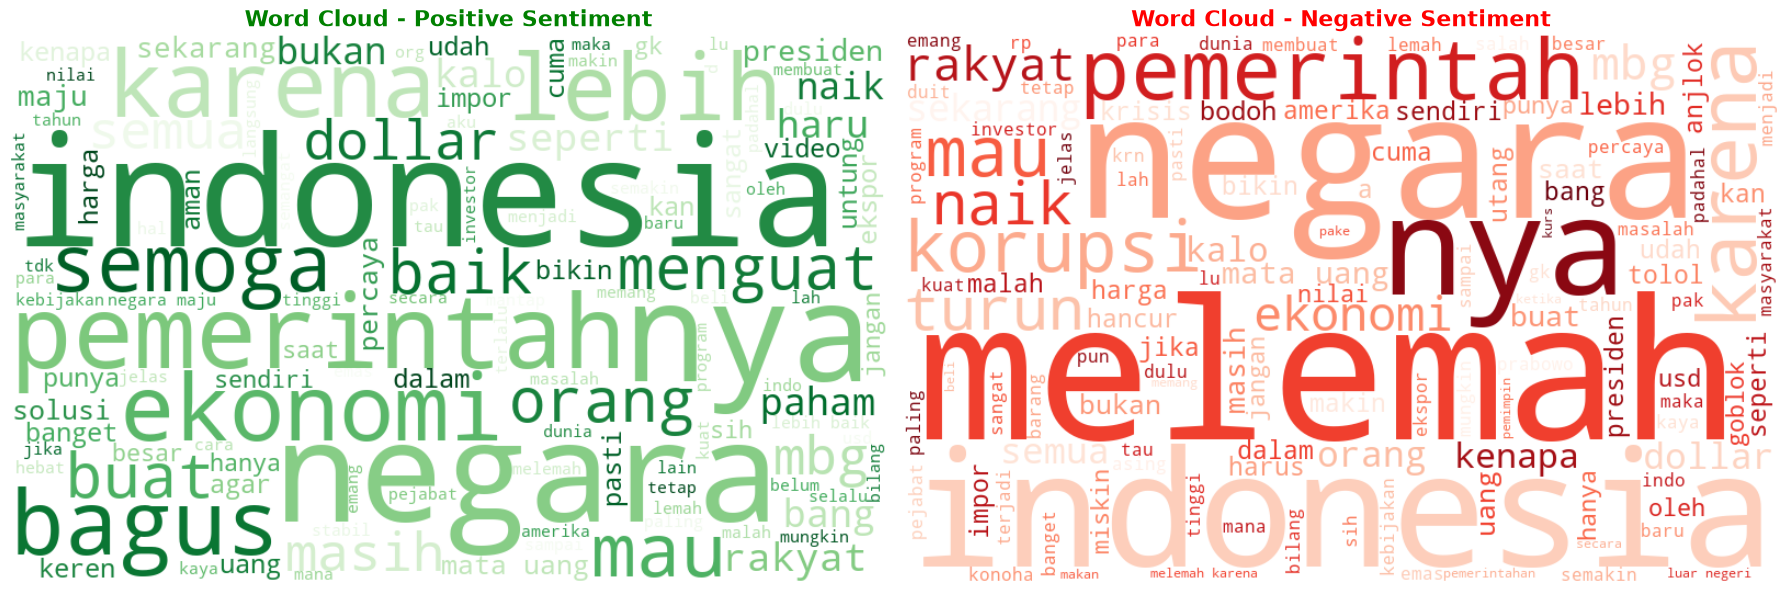

In [6]:
stopwords = set([
    'yang', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan', 'untuk', 'pada', 'adalah', 'sebagai',
    'dan', 'atau', 'juga', 'akan', 'bisa', 'sudah', 'saya', 'kita', 'kami', 'mereka', 'dia',
    'ada', 'tidak', 'tapi', 'kalau', 'lagi', 'terus', 'jadi', 'saja', 'ya', 'gak', 'udh', 'yg',
    'sama', 'banyak', 'karna', 'apa', 'biar', 'gimana', 'kok', 'dengn', 'gua', 'gw', 'dolar', 'rupiah'
])

pos_text = ' '.join(df[df['Sentiment'] == 'Positive']['Cleaned_Comment'].dropna())
neg_text = ' '.join(df[df['Sentiment'] == 'Negative']['Cleaned_Comment'].dropna())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Positive Word Cloud
wc_pos = WordCloud(width=800, height=500, background_color='white', colormap='Greens', stopwords=stopwords, max_words=120).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud - Positive Sentiment', fontsize=16, fontweight='bold', color='green')

# Negative Word Cloud
wc_neg = WordCloud(width=800, height=500, background_color='white', colormap='Reds', stopwords=stopwords, max_words=120).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud - Negative Sentiment', fontsize=16, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

### 7. Save Sentiment Results to Local CSV

In [7]:
output_file = 'rupiah_melemah_sentiment_results.csv'
df.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f'Results successfully saved to: {output_file}')

Results successfully saved to: rupiah_melemah_sentiment_results.csv
